In [1]:
import numpy as np
import torch
import torch.nn as nn
import sys
sys.path.append("../../")
from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE
from torch.utils.data import DataLoader
from vi_rnn.datasets import Reaching, Reaching_Teacher
from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from vi_rnn.utils import *
import matplotlib.pyplot as plt
from vi_rnn.saving import save_model
from py_rnn.default_params import get_default_params

%matplotlib inline

In [2]:
train_teacher = False  # load already trained teacher model
data_dir = "../../data/student_teacher/"  # store inferred model
model_dir = "../../models/students/"  # store teacher RNN
cuda = True  # toggle if GPU is available

In [3]:
# initialise teacher RNN
model_params, training_params = get_default_params(n_rec=60)
training_params["n_epochs"] = 5000
training_params["l2_rates_reg"] = 0.1
rnn_reach = RNN(model_params)

# initialise teacher RNN's task
task_params_teacher = {
    "onset": [25, 26],  # time till target stimulus onset (uniform between)
    "trial_len": 150,  # trial duration
    "stim_dur": [25, 26],  # target stimulus duration
    "n_stim": 8,  # number of stimuli locations
}
reaching = Reaching(task_params_teacher)
stimulus, target, loss_mask = reaching[1]

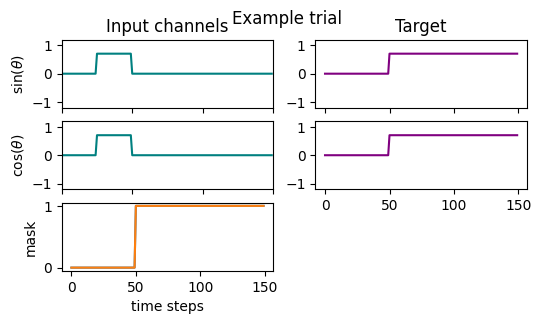

In [4]:
# Plot an example trial for teacher RNN
fig, axs = plt.subplots(3, 2, figsize=(6, 3))
fig.suptitle("Example trial")
axs[0, 0].set_title("Input channels")
axs[0, 1].set_title("Target")
axs[0, 0].set_ylabel(r"$\sin(\theta)$")
axs[1, 0].set_ylabel(r"$\cos(\theta)$")
axs[2, 0].set_ylabel("mask")

for i in range(2):
    axs[i, 0].plot(stimulus[:, i], color="teal")
    axs[i, 0].set_xlim(0, task_params_teacher["trial_len"])
    axs[i, 0].set_ylim(-1.2, 1.2)
axs[2, 0].plot(loss_mask)
for i in range(2):
    axs[i, 1].plot(target[:, i], color="purple")
    axs[i, 0].set_xlim(0, task_params_teacher["trial_len"])
    axs[i, 1].set_ylim(-1.2, 1.2)
    axs[i, 0].set_xticklabels([])
axs[0, 1].set_xticklabels([])
axs[2, 1].set_xlabel("time steps")
axs[2, 0].set_xlabel("time steps")
fig.delaxes(axs[2, 1])

In [5]:
# train or load teacher RNN
if train_teacher:
    losses, reg_losses = train_rnn(
        rnn_reach, training_params, reaching, sync_wandb=False
    )
    save_rnn(
        data_dir + "reach_rnn_new",
        rnn_reach,
        model_params,
        task_params_teacher,
        training_params,
    )
else:
    rnn_reach, model_params, task_params_teacher, training_params = load_rnn(
        data_dir + "reach_rnn"
    )

c:\Users\kaleab.belay\Documents\Project\smc_rnns\train_scripts\student_teacher\../..\py_rnn\train.py:199: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict

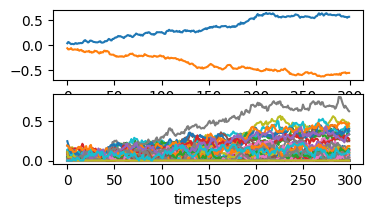

In [6]:
# plot example output
rates, pred = predict(rnn_reach, torch.zeros(300, 2))
fig, axs = plt.subplots(2, figsize=(4, 2))
axs[0].plot(pred[0, :, :])
axs[1].set_xlabel("timesteps")
axs[1].plot(rnn_reach.rnn.nonlinearity(torch.from_numpy(rates[0])));

In [7]:
# Extract weights
U, V, B = extract_orth_basis_rnn(rnn_reach)
I = rnn_reach.rnn.w_inp.detach()

In [8]:
# Generate data using teacher RNN, used for training student RNN
batch_size = 4
task_params = {
    "dur": 150,
    "n_trials": 400,
    "name": "Sine",
    "n_neurons": rnn_reach.rnn.N,
    "out": "currents",
    "w": 0.1,
    "R_x": 0.1,
    "R_z": 0.05,
    "non_lin": nn.ReLU(),
    "reach_task": reaching,
}
task = Reaching_Teacher(task_params, task_params_teacher, U, V, B, I, decay=0.9)
data_loader = DataLoader(task, batch_size=batch_size, shuffle=True)

In [9]:
task.data.shape

torch.Size([60, 400, 150])

In [10]:
task.__getitem__(0)[0].min()

tensor(-0.9421)

In [11]:
for inputs, stream in data_loader:
    print(inputs.shape, stream.shape)
    break

torch.Size([4, 60, 150]) torch.Size([4, 2, 150])


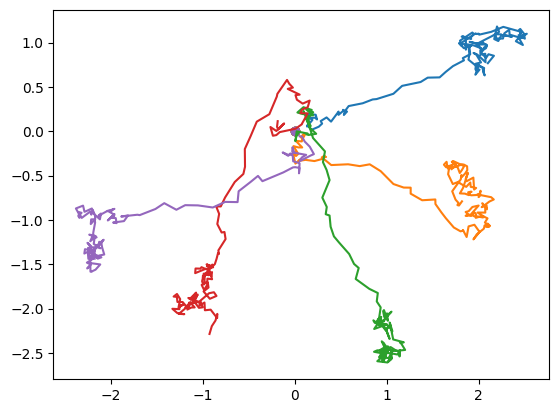

In [12]:
# Plot example latents of teacher RNN
for tr_i in range(5):
    latent_code = task.latents[:, tr_i]
    stim = task.stim[tr_i]
    plt.plot(latent_code[0], latent_code[1])
    plt.scatter(stim[50, 0], stim[50, 1])

In [13]:
# Initialise VI / student setup

dim_z = 3
dim_N = task_params["n_neurons"]
dim_x = task_params["n_neurons"]
dim_u = 2
bs = 10
cuda = True
n_epochs = 1500
wandb = False
# initialise encoder
enc_params = {"obs_grad": True, "init_scale": 0.1}

# initialise prior
prior_params = {
    "train_noise_x": True,
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.05,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.7,
    "readout_rates": task_params["out"],
    "train_obs_bias": False,
    "train_obs_weights": False,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity",
    "neuromodulators": False, 
}


training_params = {
    "lr": 1e-3,
    "lr_end": 1e-5,
    "opt_eps": 1e-8,
    "n_epochs": n_epochs,
    "grad_norm": 0,
    "bootstrap": False,
    "eval_epochs": 50000,
    "batch_size": bs,
    "cuda": cuda,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "k": 64,
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "run_eval": True,
    "smooth_at_eval": False,
    "neuromodulators": False, 
}


VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_u": dim_u,
    "dim_N": dim_N,
    "enc_architecture": "Inv_Obs",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "prior_params": prior_params,
    "causal": True,
}
vae = VAE(VAE_params)

using ReLU activation
using uniform init
weight scaler 1


In [14]:
task.data[:, 0, 0]

tensor([ 0.0663,  0.0284, -0.1089,  0.0474,  0.0276,  0.0049, -0.0310, -0.1125,
         0.0806,  0.1172,  0.1813,  0.1732, -0.1104,  0.0275,  0.1453, -0.0828,
        -0.0146,  0.0899,  0.0399, -0.0737, -0.1066, -0.0132, -0.0038, -0.2867,
        -0.0138,  0.0134, -0.1031, -0.0963, -0.1480, -0.0010, -0.0671,  0.1028,
        -0.0221, -0.0322,  0.1595,  0.0105, -0.1898, -0.0161, -0.0340,  0.0299,
         0.0602, -0.1591,  0.0985,  0.0151, -0.0971,  0.0312, -0.1409,  0.1630,
        -0.1420, -0.2423, -0.0180,  0.0097, -0.0140,  0.1428, -0.0881,  0.1395,
        -0.0602,  0.0447, -0.0449, -0.0506])

In [15]:
# Train

train_VAE(
    vae,
    training_params,
    task,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)

Training on : cuda
Learning rate decay factor 0.9969345945217527
----------------------------------------------------------------------------------------------------
Batch loss: 146.09402465820312
loss: 146.09402465820312
batch_h_loss: -6.602181911468506
batch_ll: -146.09402465820312
batch_ll_x: -143.3514404296875
----------------------------------------------------------------------------------------------------
Batch loss: 273.6813049316406
loss: 127.5872802734375
batch_h_loss: -13.215094566345215
batch_ll: -273.6813049316406
batch_ll_x: -268.56072998046875
----------------------------------------------------------------------------------------------------
Batch loss: 416.59962463378906
loss: 142.91831970214844
batch_h_loss: -19.843958377838135
batch_ll: -416.59962463378906
batch_ll_x: -408.8204040527344
----------------------------------------------------------------------------------------------------
Batch loss: 547.2661743164062
loss: 130.6665496826172
batch_h_loss: -26.490924358

KeyboardInterrupt: 

In [ ]:
save_model(vae, training_params, task_params, name=model_dir + "/reach_vae_new")